#**XỬ LÝ TIỀN DỮ LIỆU**

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from scipy.stats import ttest_ind
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report

sns.set(style="whitegrid")

In [ ]:
customers = pd.read_csv('/content/customers.csv')
orders = pd.read_csv('/content/orders.csv')
order_items = pd.read_csv('/content/order_items.csv')
payments = pd.read_csv('/content/payments.csv')
reviews = pd.read_csv('/content/reviews.csv')
returns = pd.read_csv('/content/returns.csv')
web = pd.read_csv('/content/web_traffic.csv')
inventory = pd.read_csv('/content/inventory.csv')

/tmp/ipykernel_3258/626378691.py:3: DtypeWarning: Columns (6) have mixed types. Specify dtype option on import or set low_memory=False.
  order_items = pd.read_csv('/content/order_items.csv')


In [ ]:
geography = pd.read_csv('/content/geography.csv')

# The 'geography' DataFrame does not have a 'customer_id' column. The common key is 'zip'.
# Before merging, drop the existing 'region' column from 'customers' to ensure a clean merge
# and that the region from 'geography' is used.
if 'region' in customers.columns:
    customers = customers.drop(columns=['region'])

# Merge customers with geography on 'zip' to get the region.
customers = customers.merge(geography[['zip', 'region']], on='zip', how='left')

geo_map = {
    'East': 'North',
    'Central': 'Central',
    'West': 'South'
}

# Apply the mapping to the newly obtained 'region' column.
customers['region'] = customers['region'].map(geo_map)

In [ ]:
print(customers[['gender','age_group','region']].isnull().sum())
print(customers['gender'].value_counts())
print(customers['region'].value_counts())

gender       0
age_group    0
region       0
dtype: int64
gender
Female        59640
Male          57457
Non-binary     4833
Name: count, dtype: int64
region
North      58178
Central    44286
South      19466
Name: count, dtype: int64


#**PHẦN 1 — HỌ LÀ AI**

##***NHÂN KHẨU HỌC***

In [ ]:
def summary_table(df, col):
    tbl = df[col].value_counts().reset_index()
    tbl.columns = [col, 'count']
    tbl['percent'] = tbl['count'] / tbl['count'].sum() * 100
    return tbl

display(summary_table(customers, 'gender'))
display(summary_table(customers, 'age_group'))
display(summary_table(customers, 'region'))
display(summary_table(customers, 'acquisition_channel'))

,gender,count,percent
0,Female,59640,48.913311
1,Male,57457,47.122939
2,Non-binary,4833,3.963750


,age_group,count,percent
0,25-34,36342,29.805626
1,35-44,31920,26.178955
2,45-54,23172,19.004347
3,18-24,17039,13.974412
4,55+,13457,11.036660


,region,count,percent
0,North,58178,47.714262
1,Central,44286,36.320840
2,South,19466,15.964898


,acquisition_channel,count,percent
0,organic_search,36450,29.894202
1,social_media,24448,20.050849
2,paid_search,24285,19.917166
3,email_campaign,14674,12.034774
4,referral,12270,10.063151
5,direct,9803,8.039859


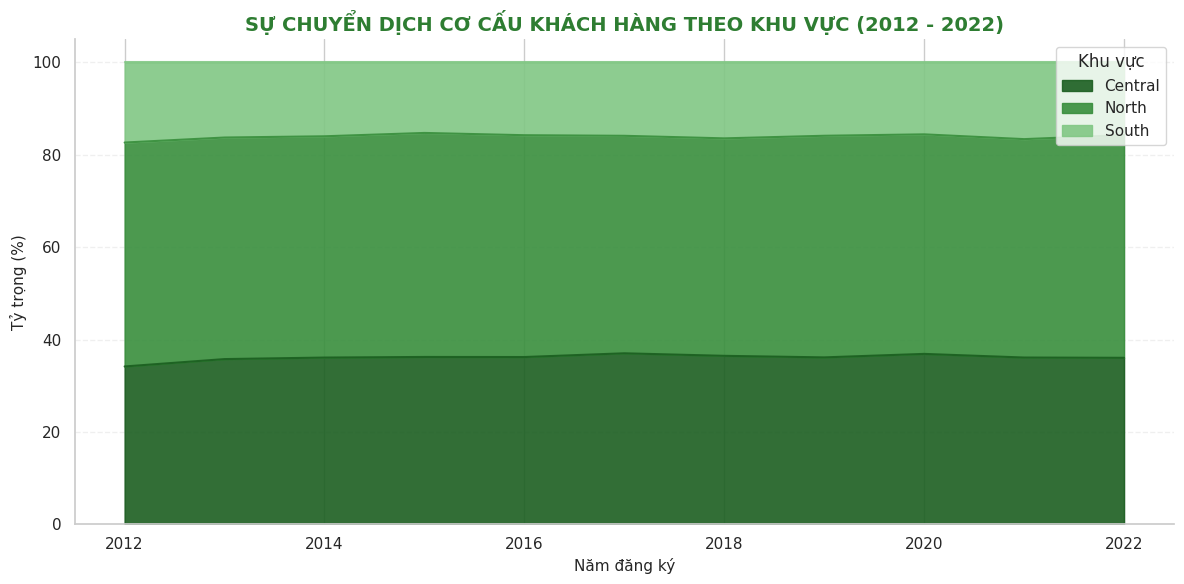

In [ ]:
# Ensure 'signup_date' is datetime
customers['signup_date'] = pd.to_datetime(customers['signup_date'])

# Extract signup year
customers['signup_year'] = customers['signup_date'].dt.year

# Filter for the relevant period (2012-2022)
customer_yearly = customers[(customers['signup_year'] >= 2012) & (customers['signup_year'] <= 2022)]

# Group by year and region, then calculate proportion
pivot = customer_yearly.groupby(['signup_year', 'region']).size().unstack(fill_value=0)
pivot = pivot.div(pivot.sum(axis=1), axis=0) * 100

plt.figure(figsize=(12,6))

# màu xanh đậm → nhạt
colors = ['#1b5e20', '#388e3c', '#81c784']

pivot.plot.area(
    ax=plt.gca(),
    color=colors,
    alpha=0.9
)

# tiêu đề
plt.title(
    "SỰ CHUYỂN DỊCH CƠ CẤU KHÁCH HÀNG THEO KHU VỰC (2012 - 2022)",
    fontsize=14,
    fontweight='bold',
    color='#2e7d32'
)

# label
plt.xlabel("Năm đăng ký", fontsize=11)
plt.ylabel("Tỷ trọng (%)", fontsize=11)

# grid nhẹ
plt.grid(axis='y', linestyle='--', alpha=0.3)

# legend đẹp hơn
plt.legend(
    title="Khu vực",
    frameon=True,
    fancybox=True,
    shadow=False,
    loc='upper right'
)


# bỏ viền xấu
sns.despine()

plt.tight_layout()
plt.show()

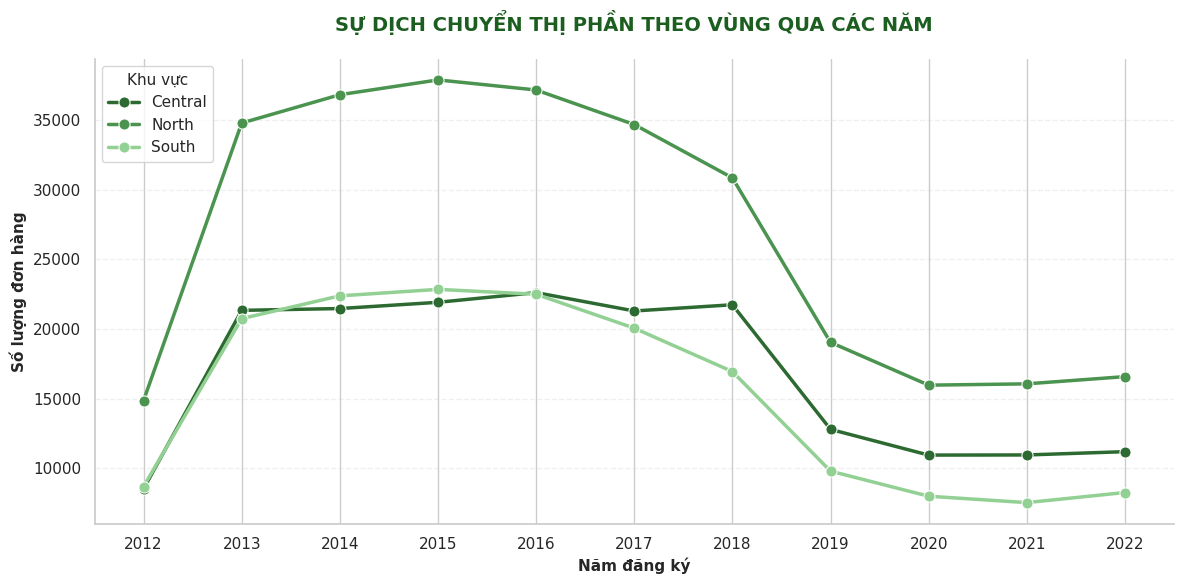

In [ ]:
# Thiết lập style và màu sắc đồng bộ với ảnh mẫu
plt.rcParams['font.family'] = 'sans-serif'
# Bảng màu xanh lá: North (Xanh vừa), Central (Xanh đậm), South (Xanh nhạt)
custom_palette = {'North': '#4b944f', 'Central': '#2d6a31', 'South': '#92d094'}

# --- CHUẨN BỊ DỮ LIỆU CHO BIỂU ĐỒ ---
# Đảm bảo 'order_date' trong DataFrame 'orders' ở định dạng datetime
orders['order_date'] = pd.to_datetime(orders['order_date'])

# Gộp 'orders' với 'customers' để lấy thông tin 'region'
orders_with_region = pd.merge(orders, customers[['customer_id', 'region']], on='customer_id', how='left')

# Trích xuất năm từ order_date
orders_with_region['year'] = orders_with_region['order_date'].dt.year

# Nhóm theo năm và khu vực để đếm số lượng đơn hàng
geo_year = orders_with_region.groupby(['year', 'region']).size().reset_index(name='orders')

# Tạo hình
plt.figure(figsize=(12, 6))

# Vẽ biểu đồ line với các tùy chỉnh marker và độ dày
sns.lineplot(
    data=geo_year,
    x='year',
    y='orders',
    hue='region',
    palette=custom_palette,
    linewidth=2.5,
    marker='o',
    markersize=8
)

# Tiêu đề tiếng Việt, viết hoa, màu xanh đậm
plt.title("SỰ DỊCH CHUYỂN THỊ PHẦN THEO VÙNG QUA CÁC NĂM",
          fontsize=14, fontweight='bold', color='#1b5e20', pad=20)

# Nhãn trục
plt.xlabel("Năm đăng ký", fontsize=11, fontweight='bold')
plt.ylabel("Số lượng đơn hàng", fontsize=11, fontweight='bold')

# Tinh chỉnh lưới và khung
sns.despine() # Bỏ khung trên và phải
plt.grid(axis='y', linestyle='--', alpha=0.3)

# Chú thích (Legend)
plt.legend(title="Khu vực", title_fontsize='11', loc='upper left', frameon=True)

# Đảm bảo trục X hiển thị đúng các năm từ 2012-2022
plt.xticks(range(2012, 2023))

plt.tight_layout()
plt.show()

##***NHU CẦU***

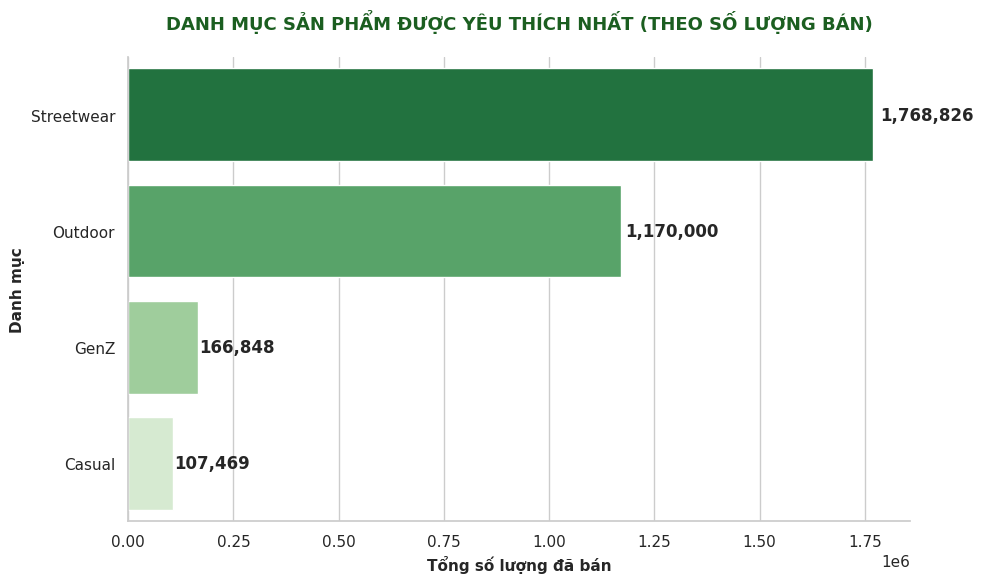

In [ ]:
# Load the products DataFrame
products = pd.read_csv('/content/products.csv')

# 1. Chuẩn bị dữ liệu: Merge order_items với products để có tên category
cat_stats = order_items.merge(products[['product_id', 'category']], on='product_id', how='left')
cat_demand = cat_stats.groupby('category')['quantity'].sum().sort_values(ascending=False).reset_index()

# 2. Vẽ biểu đồ
plt.figure(figsize=(10, 6))
sns.barplot(
    data=cat_demand,
    x='quantity',
    y='category',
    palette='Greens_r',
    hue='category',
    legend=False
)

plt.title("DANH MỤC SẢN PHẨM ĐƯỢC YÊU THÍCH NHẤT (THEO SỐ LƯỢNG BÁN)",
          fontsize=13, fontweight='bold', color='#1b5e20', pad=20)
plt.xlabel("Tổng số lượng đã bán", fontsize=11, fontweight='bold')
plt.ylabel("Danh mục", fontsize=11, fontweight='bold')

# Thêm số liệu vào đầu thanh
for i, v in enumerate(cat_demand['quantity']):
    plt.text(v + (v * 0.01), i, f'{int(v):,}', va='center', fontweight='bold')

sns.despine()
plt.tight_layout()
plt.show()

/tmp/ipykernel_3258/2452062907.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=top_prods, x='quantity', y='product_name', palette='Greens_d')


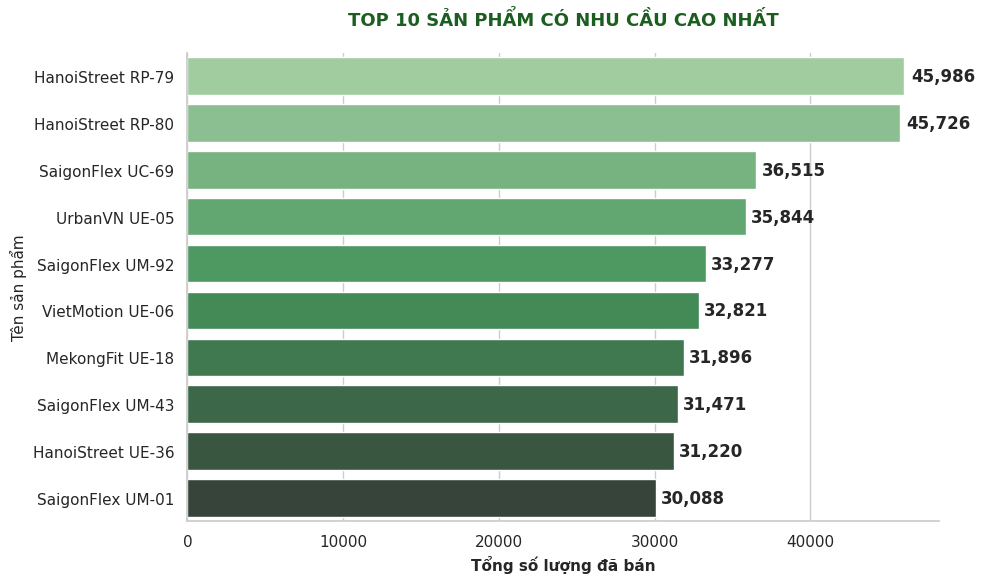

In [ ]:
# 1. Chuẩn bị dữ liệu: Lấy Top 10 sản phẩm
prod_stats = order_items.merge(products[['product_id', 'product_name']], on='product_id', how='left')
top_prods = prod_stats.groupby('product_name')['quantity'].sum().sort_values(ascending=False).head(10).reset_index()

# 2. Vẽ biểu đồ
plt.figure(figsize=(10, 6))
sns.barplot(data=top_prods, x='quantity', y='product_name', palette='Greens_d')

plt.title("TOP 10 SẢN PHẨM CÓ NHU CẦU CAO NHẤT",
          fontsize=13, fontweight='bold', color='#1b5e20', pad=20)
plt.xlabel("Tổng số lượng đã bán", fontsize=11, fontweight='bold')
plt.ylabel("Tên sản phẩm", fontsize=11)

# Thêm số liệu
for i, v in enumerate(top_prods['quantity']):
    plt.text(v + (v * 0.01), i, f'{int(v):,}', va='center', fontweight='bold')

sns.despine()
plt.tight_layout()
plt.show()

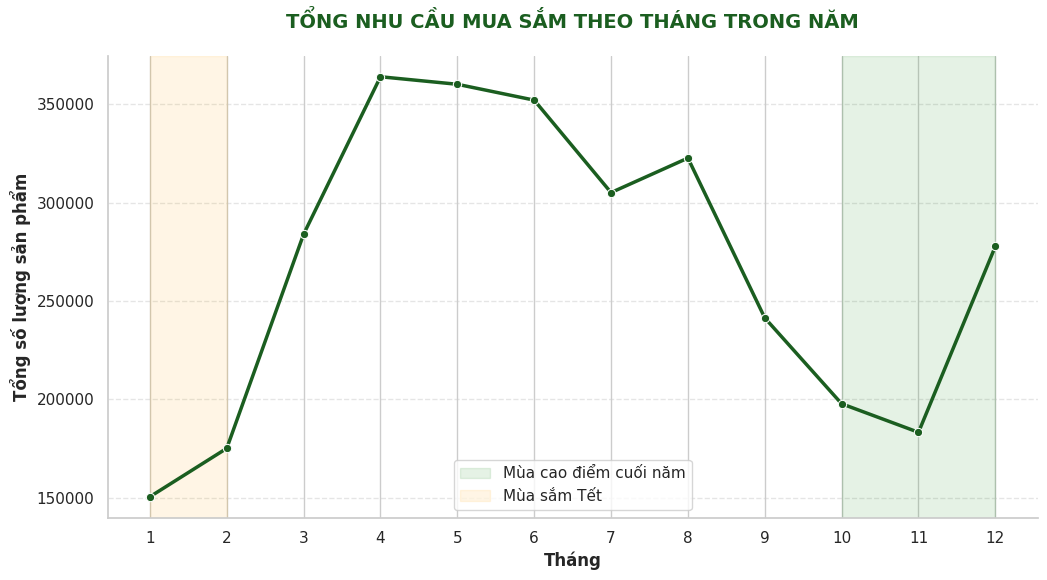

In [ ]:
# 1. Xử lý thời gian (Dùng cột order_date) - Đã sửa lỗi Index Error
col_purchase = 'order_date'
orders[col_purchase] = pd.to_datetime(orders[col_purchase])

# Trích xuất Tháng và Năm để phân tích
orders['month'] = orders[col_purchase].dt.month
orders['year_month'] = orders[col_purchase].dt.to_period('M').astype(str)

# 2. Tính tổng số lượng bán ra theo tháng (Dùng order_items để có số lượng)
monthly_demand = orders.merge(order_items, on='order_id').groupby('month')['quantity'].sum().reset_index()

# 3. Vẽ biểu đồ đường để thấy xu hướng mùa vụ
plt.figure(figsize=(12, 6))
sns.lineplot(data=monthly_demand, x='month', y='quantity', marker='o', color='#1b5e20', linewidth=2.5)

plt.title("TỔNG NHU CẦU MUA SẮM THEO THÁNG TRONG NĂM", fontsize=14, fontweight='bold', color='#1b5e20', pad=20)
plt.xlabel("Tháng", fontweight='bold')
plt.ylabel("Tổng số lượng sản phẩm", fontweight='bold')
plt.xticks(range(1, 13)) # Đảm bảo hiện đủ 12 tháng

# Thêm vùng highlight cho mùa cao điểm (ví dụ tháng 11, 12, 1)
plt.axvspan(10, 12, color='green', alpha=0.1, label='Mùa cao điểm cuối năm')
plt.axvspan(1, 2, color='orange', alpha=0.1, label='Mùa sắm Tết')

plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.legend()
sns.despine()
plt.show()

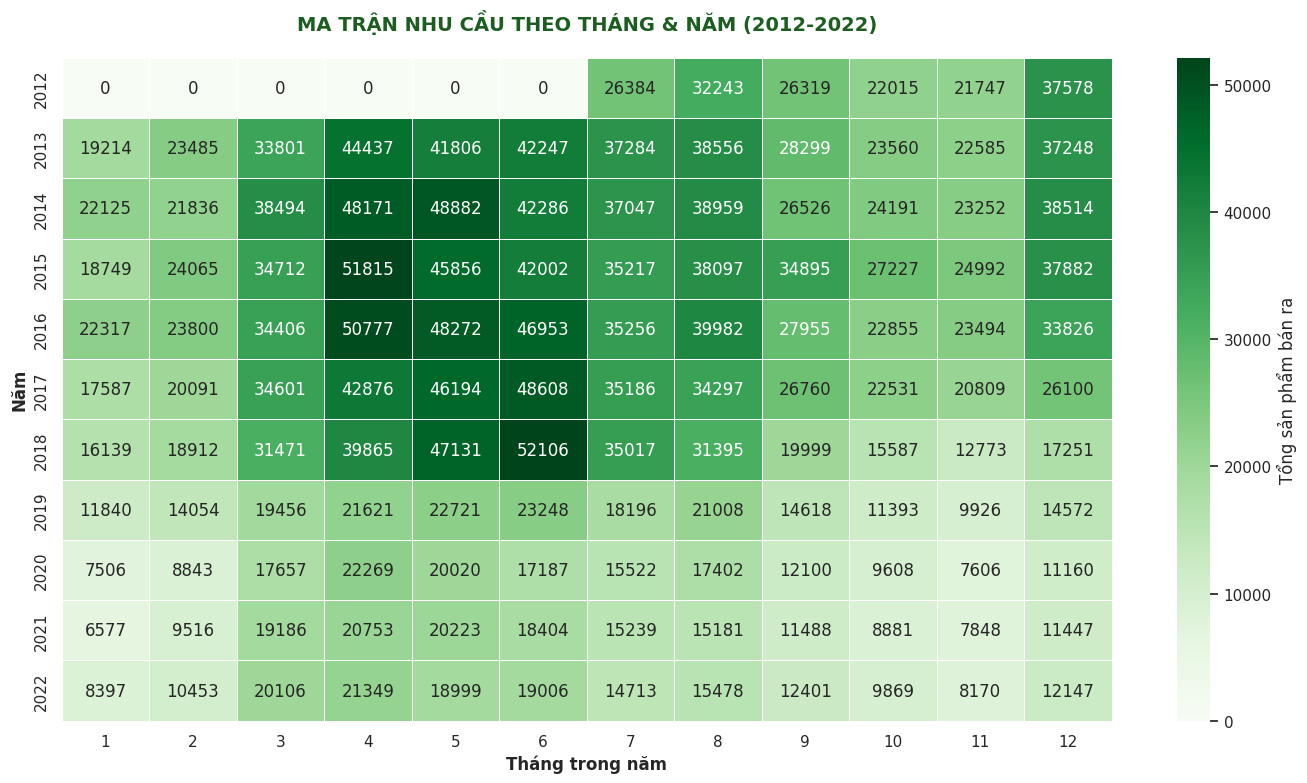

In [ ]:
# 1. Trích xuất Tháng và Năm
col_purchase = 'order_date' # Fixed: Directly use 'order_date' as the column name
orders[col_purchase] = pd.to_datetime(orders[col_purchase])
orders['Year'] = orders[col_purchase].dt.year
orders['Month'] = orders[col_purchase].dt.month

# 2. Tính số lượng đơn hàng theo tháng và năm
season_data = orders.merge(order_items, on='order_id')
season_pivot = season_data.pivot_table(
    index='Year',
    columns='Month',
    values='quantity',
    aggfunc='sum'
).fillna(0)

# 3. Vẽ Heatmap để so sánh sự lặp lại giữa các năm
plt.figure(figsize=(14, 8))
sns.heatmap(
    season_pivot,
    annot=True,
    fmt=".0f",
    cmap="Greens",
    linewidths=.5,
    cbar_kws={'label': 'Tổng sản phẩm bán ra'}
)

plt.title("MA TRẬN NHU CẦU THEO THÁNG & NĂM (2012-2022)",
          fontsize=14, fontweight='bold', color='#1b5e20', pad=20)
plt.xlabel("Tháng trong năm", fontweight='bold')
plt.ylabel("Năm", fontweight='bold')

plt.tight_layout()
plt.show()

#**PHẦN 2 - HỌ MUA NHƯ THẾ NÀO?**

##***KÊNH TIẾP CẬN***

/tmp/ipykernel_2859/3457143399.py:17: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


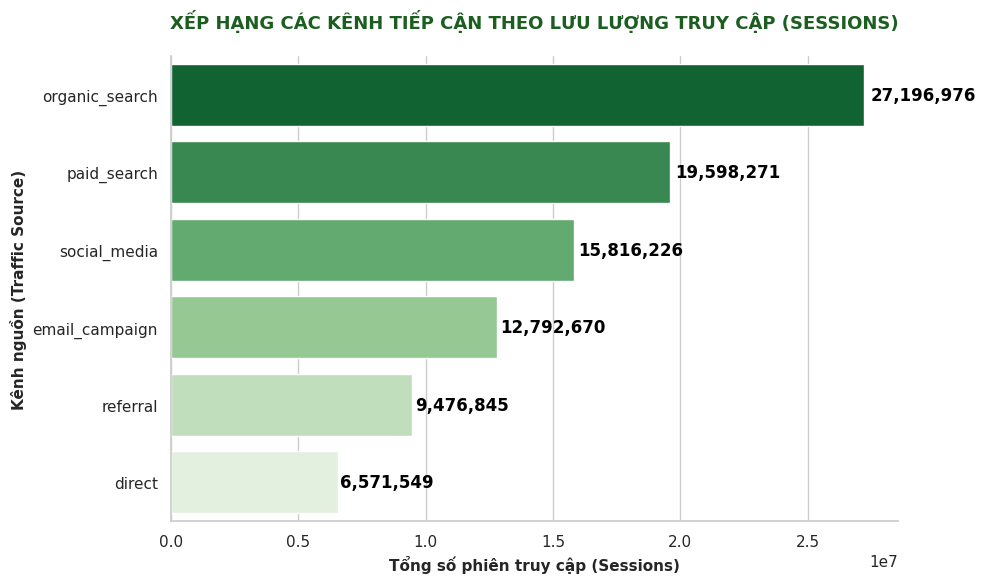

In [ ]:
# 1. Tổng hợp dữ liệu traffic theo nguồn
# Nhóm theo traffic_source và tính tổng số lượt truy cập (sessions)
traffic_summary = web.groupby('traffic_source')['sessions'].sum().reset_index()

# Sắp xếp từ cao xuống thấp để dễ quan sát
traffic_summary = traffic_summary.sort_values(by='sessions', ascending=False)

# 2. Vẽ biểu đồ
plt.figure(figsize=(10, 6))
plt.rcParams['font.family'] = 'sans-serif'

# Sử dụng bảng màu xanh lá đậm dần (Greens_r) để làm nổi bật kênh cao nhất
sns.barplot(
    data=traffic_summary,
    x='sessions',
    y='traffic_source',
    palette='Greens_r'
)

# 3. Tùy chỉnh thẩm mỹ theo phong cách The Gridbreakers
plt.title("XẾP HẠNG CÁC KÊNH TIẾP CẬN THEO LƯU LƯỢNG TRUY CẬP (SESSIONS)",
          fontsize=13, fontweight='bold', color='#1b5e20', pad=20)

plt.xlabel("Tổng số phiên truy cập (Sessions)", fontsize=11, fontweight='bold')
plt.ylabel("Kênh nguồn (Traffic Source)", fontsize=11, fontweight='bold')

# Thêm số liệu cụ thể ở đầu mỗi thanh để dễ đọc (giúp đạt điểm cao phần mô tả)
for i, v in enumerate(traffic_summary['sessions']):
    plt.text(v + (v * 0.01), i, f'{int(v):,}', color='black', va='center', fontweight='bold')

sns.despine() # Bỏ khung trên và phải
plt.tight_layout()
plt.show()

/tmp/ipykernel_2859/249563245.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=traffic_quality, x='bounce_rate', y='traffic_source', ax=ax1, palette='Reds_r')
/tmp/ipykernel_2859/249563245.py:15: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=traffic_quality, x='avg_session_duration_sec', y='traffic_source', ax=ax2, palette='Greens')


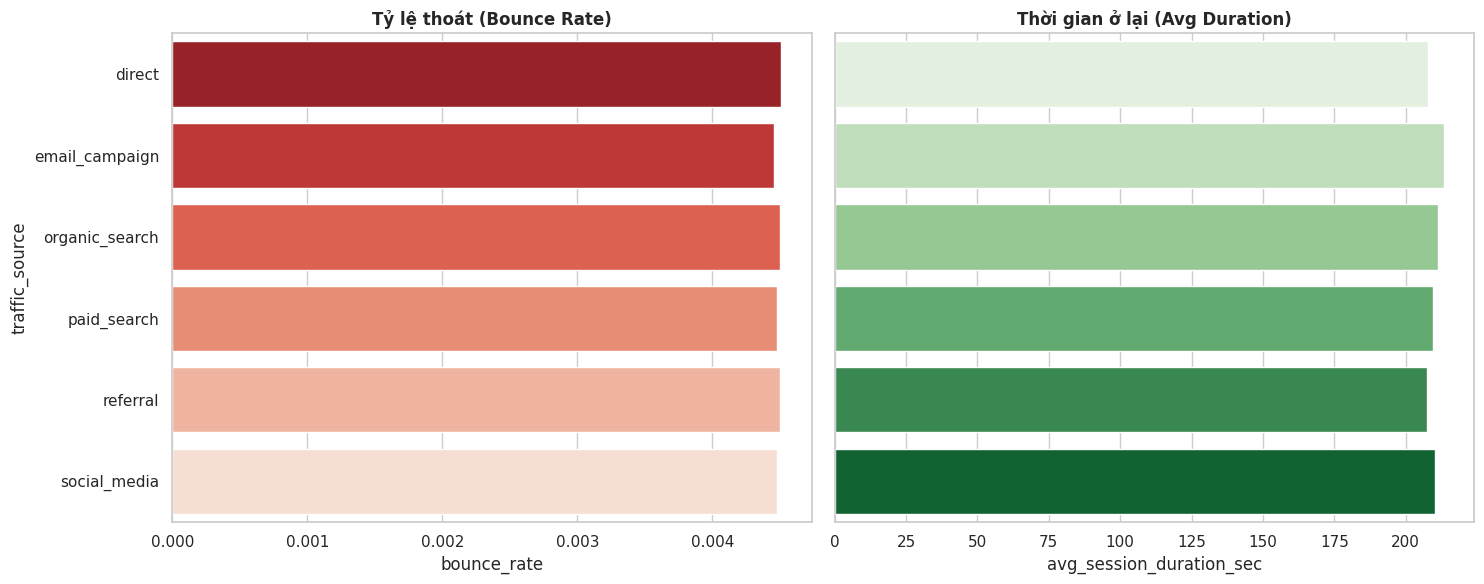

In [ ]:
traffic_quality = web.groupby('traffic_source').agg({
    'bounce_rate': 'mean',
    'avg_session_duration_sec': 'mean'
}).reset_index()

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6), sharey=True)

# Biểu đồ 1: Bounce Rate (Càng ngắn càng tốt)
sns.barplot(data=traffic_quality, x='bounce_rate', y='traffic_source', ax=ax1, palette='Reds_r')
ax1.set_title("Tỷ lệ thoát (Bounce Rate)", fontweight='bold')

# Biểu đồ 2: Session Duration (Càng dài càng tốt)
sns.barplot(data=traffic_quality, x='avg_session_duration_sec', y='traffic_source', ax=ax2, palette='Greens')
ax2.set_title("Thời gian ở lại (Avg Duration)", fontweight='bold')

plt.tight_layout()
plt.show()

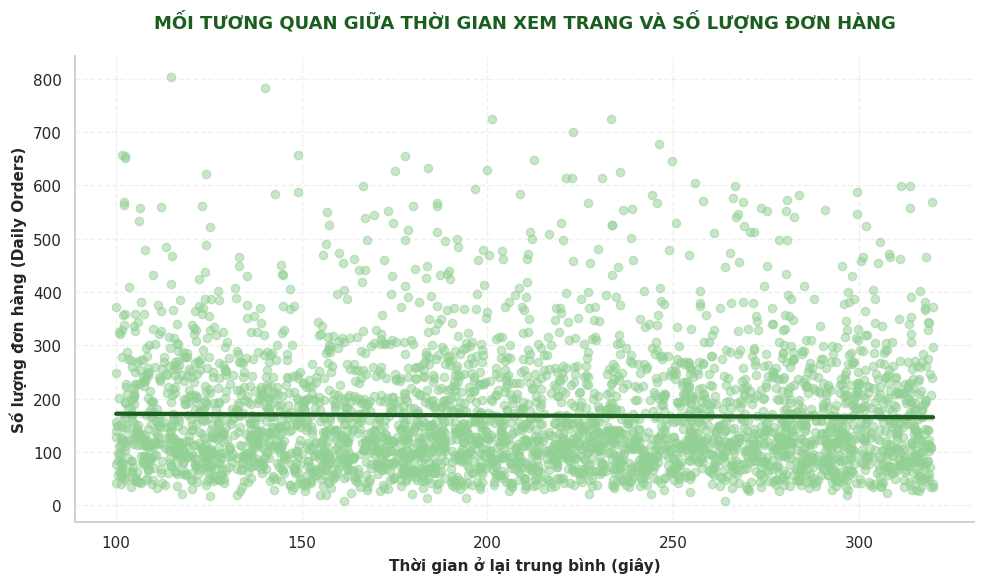

In [ ]:
# 1. Chuẩn bị dữ liệu (Giữ nguyên logic của bạn)
daily_orders = orders.groupby('order_date').size().reset_index(name='orders')
web['date'] = pd.to_datetime(web['date'])
merged = web.merge(daily_orders, left_on='date', right_on='order_date')

# 2. Vẽ biểu đồ với tùy chỉnh màu sắc và font
plt.figure(figsize=(10, 6))
plt.rcParams['font.family'] = 'sans-serif'

# Vẽ scatter plot với đường hồi quy (regplot)
# Sử dụng màu xanh đậm cho đường hồi quy và xanh nhạt cho các điểm dữ liệu
sns.regplot(
    data=merged,
    x='avg_session_duration_sec',
    y='orders',
    scatter_kws={'alpha':0.5, 'color': '#92d094'}, # Màu xanh nhạt cho điểm
    line_kws={'color': '#1b5e20', 'lw': 3}         # Màu xanh đậm cho đường hồi quy
)

# 3. Tùy chỉnh tiêu đề và nhãn tiếng Việt
plt.title("MỐI TƯƠNG QUAN GIỮA THỜI GIAN XEM TRANG VÀ SỐ LƯỢNG ĐƠN HÀNG",
          fontsize=13, fontweight='bold', color='#1b5e20', pad=20)

plt.xlabel("Thời gian ở lại trung bình (giây)", fontsize=11, fontweight='bold')
plt.ylabel("Số lượng đơn hàng (Daily Orders)", fontsize=11, fontweight='bold')

# Làm đẹp khung hình
sns.despine()
plt.grid(True, linestyle='--', alpha=0.3)

plt.tight_layout()
plt.show()

##***KÊNH MUA***

/tmp/ipykernel_2859/3113446639.py:15: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


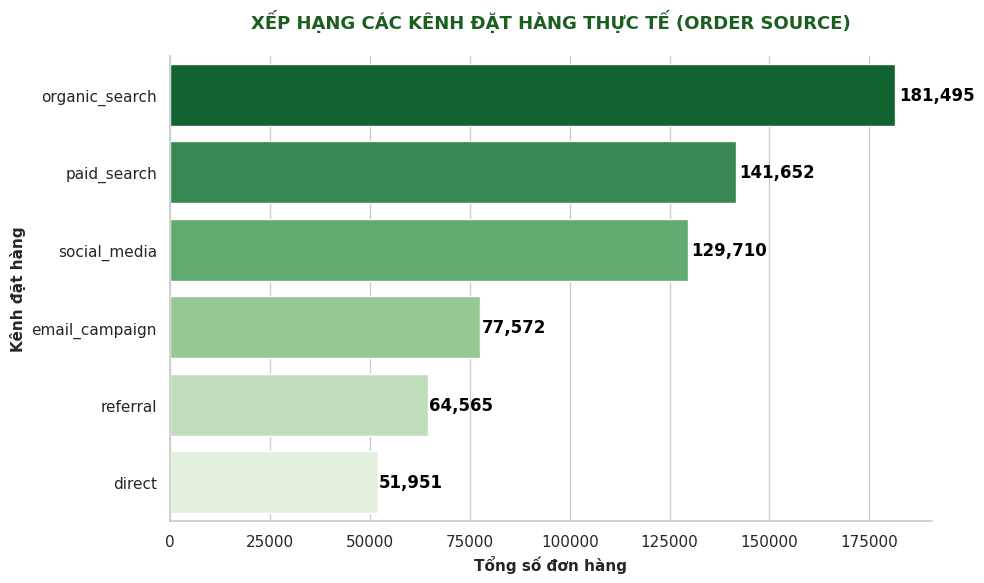

In [ ]:
# 1. Thống kê số lượng đơn hàng theo kênh mua (Order Source)
# Đếm số lượng đơn hàng cho mỗi nguồn
order_source_stats = orders['order_source'].value_counts().reset_index()
order_source_stats.columns = ['order_source', 'order_count']

# 2. Vẽ biểu đồ thanh ngang
plt.figure(figsize=(10, 6))
plt.rcParams['font.family'] = 'sans-serif'

# Dùng màu xanh lá đậm dần để làm nổi bật kênh cao nhất
sns.barplot(
    data=order_source_stats,
    x='order_count',
    y='order_source',
    palette='Greens_r'
)

# 3. Tùy chỉnh thẩm mỹ theo phong cách báo cáo
plt.title("XẾP HẠNG CÁC KÊNH ĐẶT HÀNG THỰC TẾ (ORDER SOURCE)",
          fontsize=13, fontweight='bold', color='#1b5e20', pad=20)

plt.xlabel("Tổng số đơn hàng", fontsize=11, fontweight='bold')
plt.ylabel("Kênh đặt hàng", fontsize=11, fontweight='bold')

# Thêm số liệu trực tiếp trên đầu thanh để dễ đọc insight
for i, v in enumerate(order_source_stats['order_count']):
    plt.text(v + (v * 0.005), i, f'{int(v):,}', color='black', va='center', fontweight='bold')

sns.despine()
plt.tight_layout()
plt.show()

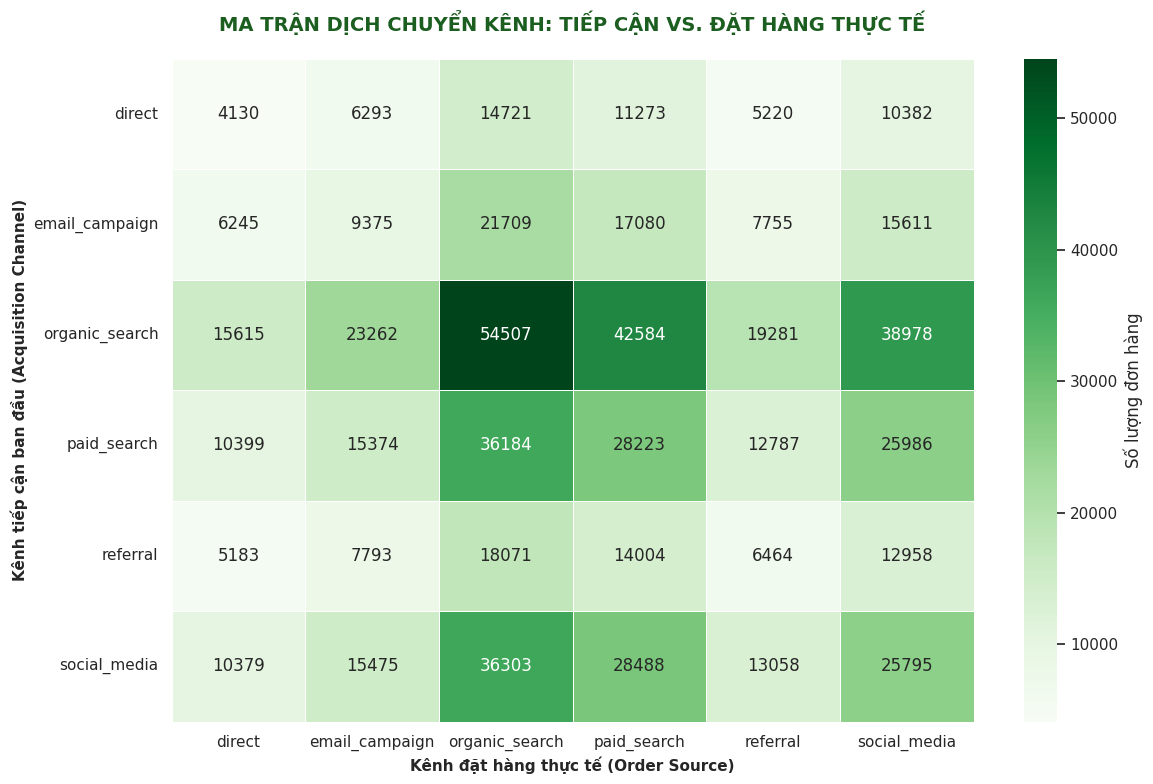

In [ ]:
# 1. Chuẩn bị dữ liệu (Lưu ý dùng đúng tên bảng 'web' hoặc 'customers' bạn đang có)
# Merge để lấy kênh tiếp cận của khách hàng cho mỗi đơn hàng
orders_full = orders.merge(customers[['customer_id', 'acquisition_channel']], on='customer_id', how='left')

# 2. Tạo bảng chéo (Pivot Table) tính số lượng đơn hàng
# Index là kênh tiếp cận, Columns là kênh mua thực tế
heatmap_data = pd.crosstab(orders_full['acquisition_channel'], orders_full['order_source'])

# 3. Vẽ Heatmap
plt.figure(figsize=(12, 8))
plt.rcParams['font.family'] = 'sans-serif'

sns.heatmap(
    heatmap_data,
    annot=True,          # Hiển thị số lượng cụ thể vào từng ô
    fmt="d",             # Định dạng số nguyên
    cmap="Greens",       # Màu xanh lá đậm dần theo ảnh mẫu
    linewidths=.5,       # Đường kẻ giữa các ô cho rõ ràng
    cbar_kws={'label': 'Số lượng đơn hàng'}
)

# 4. Việt hóa và chỉnh font
plt.title("MA TRẬN DỊCH CHUYỂN KÊNH: TIẾP CẬN VS. ĐẶT HÀNG THỰC TẾ",
          fontsize=14, fontweight='bold', color='#1b5e20', pad=20)

plt.xlabel("Kênh đặt hàng thực tế (Order Source)", fontsize=11, fontweight='bold')
plt.ylabel("Kênh tiếp cận ban đầu (Acquisition Channel)", fontsize=11, fontweight='bold')

plt.tight_layout()
plt.show()

##***KHUYẾN MÃI***

/tmp/ipykernel_2859/3275958362.py:19: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


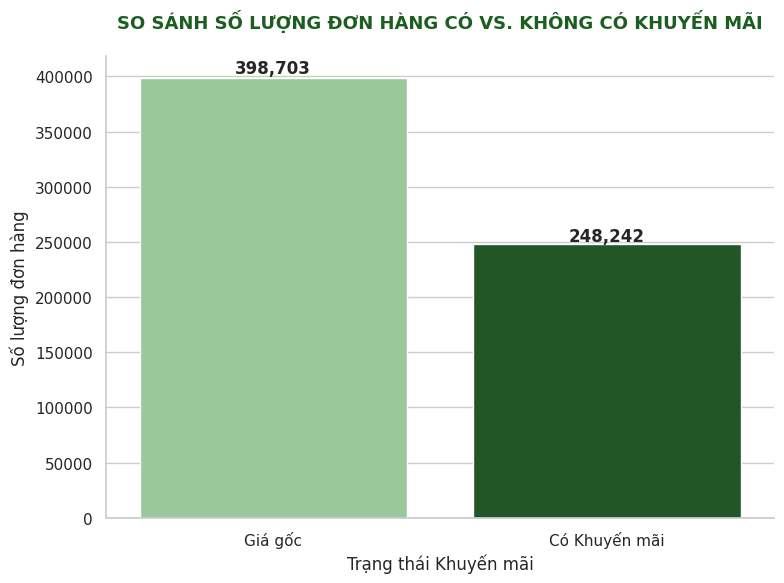

In [ ]:
# 1. Xác định đơn hàng có khuyến mãi hay không
# Lưu ý: Một đơn hàng có thể có nhiều sản phẩm, chỉ cần 1 sản phẩm có promo là đơn đó có promo
order_items['has_promo'] = order_items['promo_id'].notnull()
promo_status = order_items.groupby('order_id')['has_promo'].any().reset_index()

# 2. Đếm số lượng đơn hàng
promo_counts = promo_status['has_promo'].value_counts().reset_index()
promo_counts.columns = ['Trạng thái Khuyến mãi', 'Số lượng đơn hàng']
promo_counts['Trạng thái Khuyến mãi'] = promo_counts['Trạng thái Khuyến mãi'].map({True: 'Có Khuyến mãi', False: 'Giá gốc'})

# 3. Vẽ biểu đồ
plt.figure(figsize=(8, 6))
plt.rcParams['font.family'] = 'sans-serif'

sns.barplot(
    data=promo_counts,
    x='Trạng thái Khuyến mãi',
    y='Số lượng đơn hàng',
    palette=['#92d094', '#1b5e20'] # Xanh nhạt cho giá gốc, xanh đậm cho khuyến mãi
)

# Thêm tiêu đề và nhãn
plt.title("SO SÁNH SỐ LƯỢNG ĐƠN HÀNG CÓ VS. KHÔNG CÓ KHUYẾN MÃI",
          fontsize=13, fontweight='bold', color='#1b5e20', pad=20)

# Thêm số liệu cụ thể trên cột
for i, v in enumerate(promo_counts['Số lượng đơn hàng']):
    plt.text(i, v + (v * 0.01), f'{int(v):,}', ha='center', fontweight='bold')

sns.despine()
plt.tight_layout()
plt.show()

In [ ]:
order_items['has_promo'] = order_items['promo_id'].notnull()

aov = order_items.groupby('has_promo')['unit_price'].mean()

print(aov)

has_promo
False    5575.082823
True     4384.314405
Name: unit_price, dtype: float64


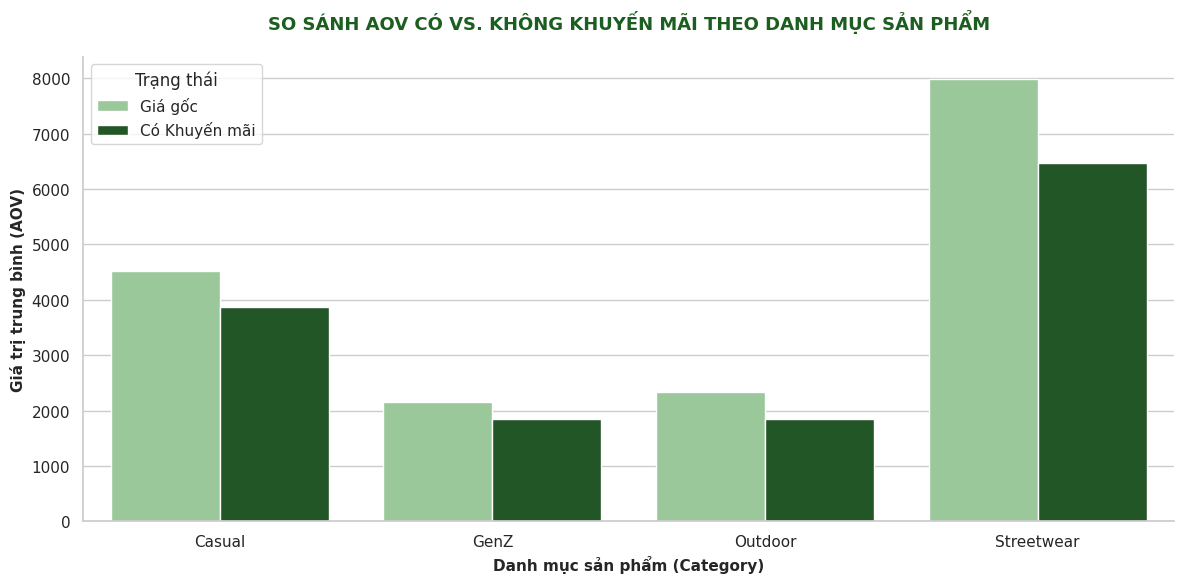

In [ ]:
# Load the products DataFrame
products = pd.read_csv('/content/products.csv')

# 1. Kết nối dữ liệu items với thông tin sản phẩm (để lấy category)
items_with_cat = order_items.merge(products[['product_id', 'category']], on='product_id', how='left')

# 2. Xác định trạng thái khuyến mãi
items_with_cat['has_promo'] = items_with_cat['promo_id'].notnull()

# 3. Tính AOV theo từng Category và Trạng thái khuyến mãi
# AOV ở đây tính bằng trung bình cộng giá trị các dòng sản phẩm (unit_price)
aov_compare = items_with_cat.groupby(['category', 'has_promo'])['unit_price'].mean().reset_index()

# Việt hóa nhãn để đưa vào báo cáo
aov_compare['Promo Status'] = aov_compare['has_promo'].map({True: 'Có Khuyến mãi', False: 'Giá gốc'})

# 4. Vẽ biểu đồ Bar nhóm (Grouped Bar Chart)
plt.figure(figsize=(12, 6))
plt.rcParams['font.family'] = 'sans-serif'

sns.barplot(
    data=aov_compare,
    x='category',
    y='unit_price',
    hue='Promo Status',
    palette=['#92d094', '#1b5e20'] # Màu xanh theo style The Gridbreakers
)

# 5. Tùy chỉnh thẩm mỹ
plt.title("SO SÁNH AOV CÓ VS. KHÔNG KHUYẾN MÃI THEO DANH MỤC SẢN PHẨM",
          fontsize=13, fontweight='bold', color='#1b5e20', pad=20)

plt.xlabel("Danh mục sản phẩm (Category)", fontsize=11, fontweight='bold')
plt.ylabel("Giá trị trung bình (AOV)", fontsize=11, fontweight='bold')
plt.legend(title="Trạng thái")

sns.despine()
plt.tight_layout()
plt.show()

##***TRẢ GÓP***

In [ ]:
# 1. Merge và Phân loại
orders_with_payments = orders.merge(payments[['order_id', 'installments', 'payment_value']], on='order_id', how='left')
orders_with_payments['payment_type'] = orders_with_payments['installments'].apply(lambda x: 'Trả góp' if x > 1 else 'Trả thẳng')

# 2. Tính toán bảng thống kê
payment_summary = orders_with_payments.groupby('payment_type').agg(
    AOV=('payment_value', 'mean'),
    Total_Revenue=('payment_value', 'sum'),
    Order_Count=('order_id', 'count')
).reset_index()

# 3. Định dạng: Giữ dấu chấm thập phân (2 chữ số), không dùng dấu phẩy hàng nghìn
# Cách này giúp số liệu trông đồng nhất với định dạng dummy data gốc của bạn
pd.options.display.float_format = '{:.2f}'.format

# 4. In bảng kết quả
print("--- BẢNG THỐNG KÊ THANH TOÁN")
print(payment_summary.to_string(index=False))

--- BẢNG THỐNG KÊ THANH TOÁN
payment_type      AOV  Total_Revenue  Order_Count
     Trả góp 24323.93  9342309338.58       384079
   Trả thẳng 24113.27  6338559926.85       262866


#**PHẦN 3 - HẬU MÃI & RỦI RO**

/tmp/ipykernel_2859/2207918814.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=return_reasons.head(10), x='Số lượng', y='Lý do', palette='Reds_r')


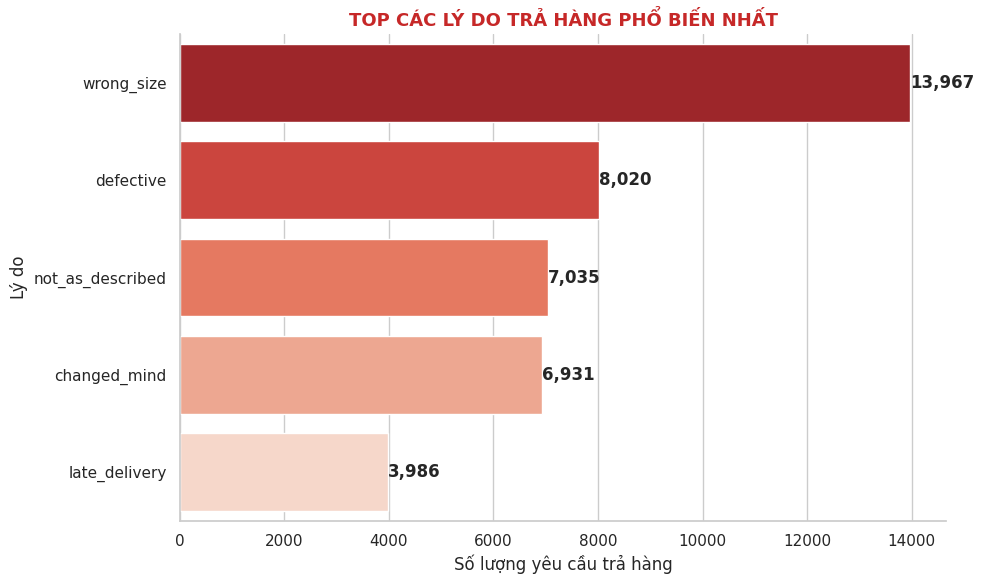

In [ ]:
# 1. Đếm các lý do trả hàng
# Lưu ý: Thay 'return_reason' bằng tên cột chính xác trong file returns.csv của bạn
return_reasons = returns['return_reason'].value_counts().reset_index()
return_reasons.columns = ['Lý do', 'Số lượng']

# 2. Vẽ biểu đồ
plt.figure(figsize=(10, 6))
sns.barplot(data=return_reasons.head(10), x='Số lượng', y='Lý do', palette='Reds_r')

plt.title("TOP CÁC LÝ DO TRẢ HÀNG PHỔ BIẾN NHẤT", fontsize=13, fontweight='bold', color='#c62828')
plt.xlabel("Số lượng yêu cầu trả hàng")
plt.ylabel("Lý do")

# Thêm số liệu
for i, v in enumerate(return_reasons.head(10)['Số lượng']):
    plt.text(v + 3, i, f'{int(v):,}', va='center', fontweight='bold')

sns.despine()
plt.tight_layout()
plt.show()

/tmp/ipykernel_2859/1591112274.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=bad_reasons, x='Số lượng', y='Nội dung phàn nàn', palette='Oranges_r')


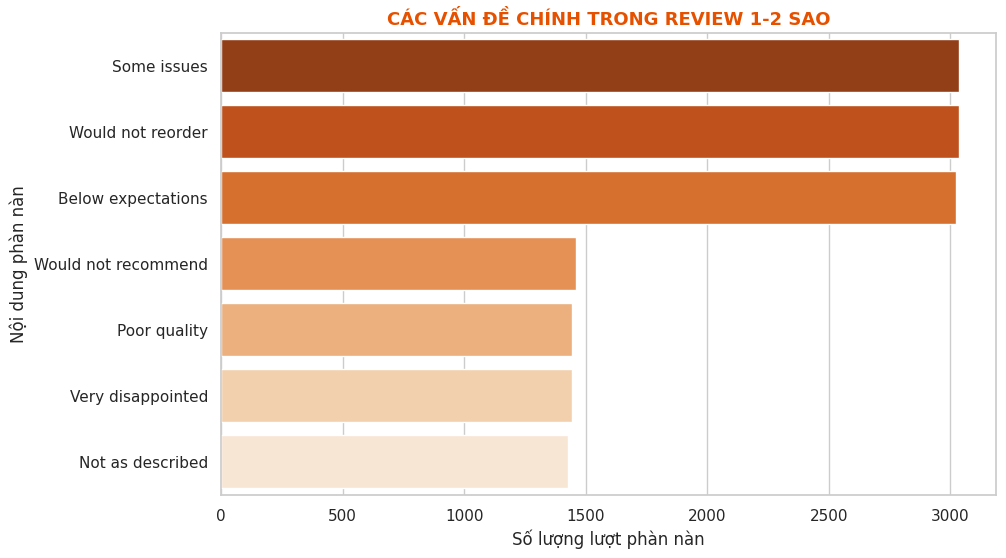

In [ ]:
# 1. Lọc các review tiêu cực (1-2 sao)
negative_reviews = reviews[reviews['rating'] <= 2]

# 2. Thống kê các tiêu đề review hoặc lý do phàn nàn (nếu có cột phân loại)
# Giả sử cột chứa nội dung là 'review_title' hoặc 'reason_category'
bad_reasons = negative_reviews['review_title'].value_counts().head(10).reset_index()
bad_reasons.columns = ['Nội dung phàn nàn', 'Số lượng']

# 3. Vẽ biểu đồ
plt.figure(figsize=(10, 6))
sns.barplot(data=bad_reasons, x='Số lượng', y='Nội dung phàn nàn', palette='Oranges_r')

plt.title("CÁC VẤN ĐỀ CHÍNH TRONG REVIEW 1-2 SAO", fontsize=13, fontweight='bold', color='#e65100')
plt.xlabel("Số lượng lượt phàn nàn")
plt.show()

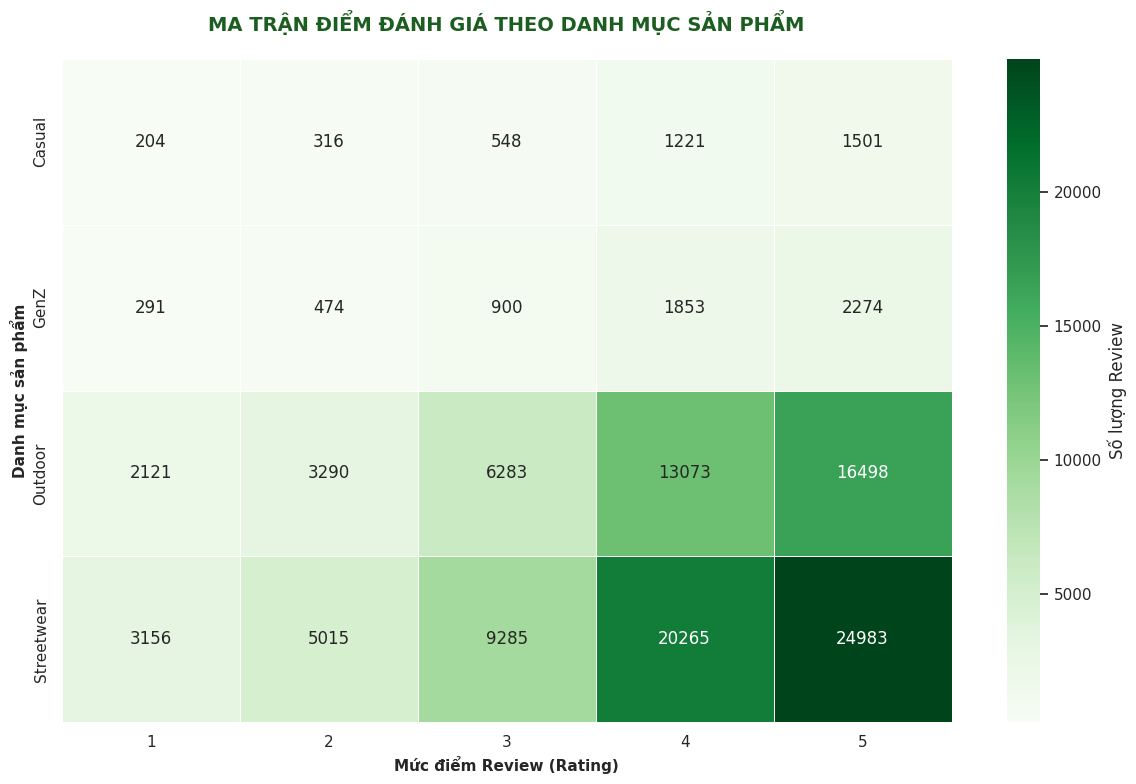

In [ ]:
# 1. Merge dữ liệu
# Lưu ý: Merge trực tiếp trên product_id như bạn làm là chuẩn nếu bảng reviews có sẵn product_id
review_data = reviews.merge(products[['product_id', 'category']], on='product_id', how='left')

# 2. Tạo bảng chéo
review_matrix = pd.crosstab(review_data['category'], review_data['rating'])

# 3. Vẽ Heatmap với concept Xanh lá
plt.figure(figsize=(12, 8))
plt.rcParams['font.family'] = 'sans-serif'

# cmap="Greens" sẽ đi từ trắng đến xanh lá đậm
# robust=True giúp màu sắc phân bổ đều hơn nếu có ô quá lớn
sns.heatmap(
    review_matrix,
    annot=True,
    fmt="d",
    cmap="Greens",
    linewidths=.5,
    cbar_kws={'label': 'Số lượng Review'}
)

# 4. Tùy chỉnh tiêu đề và nhãn theo style Trang 1
plt.title("MA TRẬN ĐIỂM ĐÁNH GIÁ THEO DANH MỤC SẢN PHẨM",
          fontsize=14, fontweight='bold', color='#1b5e20', pad=20)

plt.xlabel("Mức điểm Review (Rating)", fontsize=11, fontweight='bold')
plt.ylabel("Danh mục sản phẩm", fontsize=11, fontweight='bold')

plt.tight_layout()
plt.show()

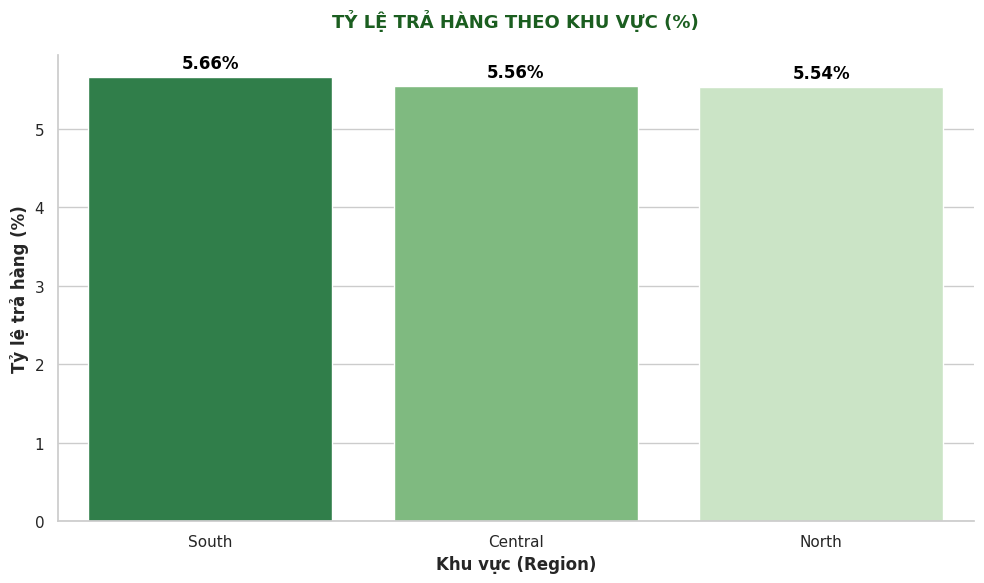

In [ ]:
# 1. Xác định đơn hàng có bị trả hay không (Dựa trên bảng returns)
# Merge orders với customers để lấy vùng miền
orders_geo = orders.merge(customers[['customer_id', 'region']], on='customer_id', how='left')

# Tạo cột is_returned: 1 nếu có trong bảng returns, 0 nếu không
orders_geo['is_returned'] = orders_geo['order_id'].isin(returns['order_id']).astype(int)

# 2. Tính tỷ lệ trả hàng theo khu vực
return_rate = orders_geo.groupby('region')['is_returned'].mean().reset_index()
return_rate['return_rate_pct'] = return_rate['is_returned'] * 100
return_rate = return_rate.sort_values('return_rate_pct', ascending=False)

# 3. Vẽ biểu đồ
plt.figure(figsize=(10, 6))
sns.barplot(
    data=return_rate,
    x='region',
    y='return_rate_pct',
    palette='Greens_r',
    hue='region', # Assign x variable to hue to resolve FutureWarning
    legend=False  # Set legend=False as hue is now assigned
)

# Tùy chỉnh thẩm mỹ
plt.title("TỶ LỆ TRẢ HÀNG THEO KHU VỰC (%)", fontsize=13, fontweight='bold', color='#1b5e20', pad=20)
plt.ylabel("Tỷ lệ trả hàng (%)", fontweight='bold')
plt.xlabel("Khu vực (Region)", fontweight='bold')

# Thêm nhãn số % trên đầu cột
for i, v in enumerate(return_rate['return_rate_pct']):
    plt.text(i, v + (v*0.02), f'{v:.2f}%', ha='center', fontweight='bold', color='black')

sns.despine()
plt.tight_layout()
plt.show()

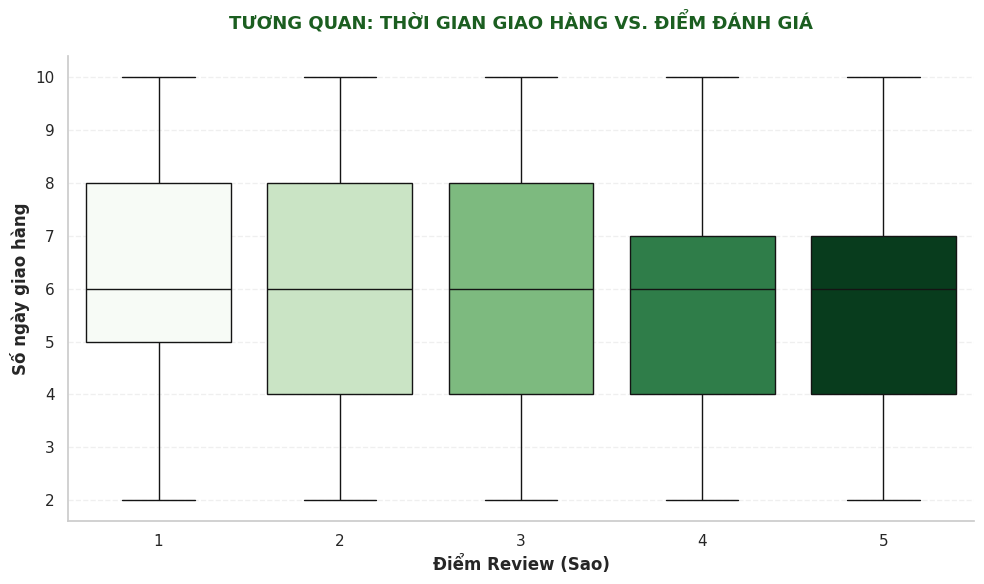

In [ ]:
# Load the shipments data
shipments = pd.read_csv('/content/shipments.csv')

# 1. Merge orders with shipments to get delivery date
orders_with_delivery = orders.merge(shipments[['order_id', 'delivery_date']], on='order_id', how='left')

# 2. Convert date columns to datetime objects
orders_with_delivery['order_date'] = pd.to_datetime(orders_with_delivery['order_date'])
orders_with_delivery['delivery_date'] = pd.to_datetime(orders_with_delivery['delivery_date'])

# 3. Calculate delivery time in days
orders_with_delivery['delivery_time'] = (orders_with_delivery['delivery_date'] - orders_with_delivery['order_date']).dt.days

# 4. Merge with reviews to get ratings
delivery_review = orders_with_delivery.merge(reviews[['order_id', 'rating']], on='order_id', how='inner')

# Remove rows with missing or negative delivery times
delivery_review = delivery_review.dropna(subset=['delivery_time'])
delivery_review = delivery_review[delivery_review['delivery_time'] >= 0]

# 5. Plotting
plt.figure(figsize=(10, 6))
plt.rcParams['font.family'] = 'sans-serif'

sns.boxplot(
    data=delivery_review,
    x='rating',
    y='delivery_time',
    palette='Greens',
    hue='rating', # Assign x variable to hue to resolve FutureWarning
    legend=False, # Set legend=False as hue is now assigned
    showfliers=False # Hide outliers for a cleaner plot
)

plt.title("TƯƠNG QUAN: THỜI GIAN GIAO HÀNG VS. ĐIỂM ĐÁNH GIÁ",
          fontsize=13, fontweight='bold', color='#1b5e20', pad=20)
plt.xlabel("Điểm Review (Sao)", fontweight='bold')
plt.ylabel("Số ngày giao hàng", fontweight='bold')

plt.grid(axis='y', linestyle='--', alpha=0.3)
sns.despine()
plt.tight_layout()
plt.show()